In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import files
uploaded = files.upload()

import io
cc_data = pd.read_csv(io.BytesIO(uploaded['TW_credit.csv']))

Saving TW_credit.csv to TW_credit.csv


In [ ]:
cc_data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


In [ ]:
cc_data.shape

(30000, 25)

In [3]:
# Pre-processing
# Drop the ID column
# Rename the target column for easier handling

cc_data.drop(['ID'], axis=1, inplace=True)
cc_data.rename(columns={"default payment next month": "DEFAULT"}, inplace=True)

In [4]:
# Change data types for categorical variables
# Dummy code categorical features

cc_data['SEX'] = cc_data['SEX'].astype('category')
cc_data['EDUCATION'] = cc_data['EDUCATION'].astype('category')
cc_data['MARRIAGE'] = cc_data['MARRIAGE'].astype('category')
cc_data = pd.get_dummies(cc_data)

In [ ]:
cc_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 34 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   LIMIT_BAL    30000 non-null  int64
 1   AGE          30000 non-null  int64
 2   PAY_0        30000 non-null  int64
 3   PAY_2        30000 non-null  int64
 4   PAY_3        30000 non-null  int64
 5   PAY_4        30000 non-null  int64
 6   PAY_5        30000 non-null  int64
 7   PAY_6        30000 non-null  int64
 8   BILL_AMT1    30000 non-null  int64
 9   BILL_AMT2    30000 non-null  int64
 10  BILL_AMT3    30000 non-null  int64
 11  BILL_AMT4    30000 non-null  int64
 12  BILL_AMT5    30000 non-null  int64
 13  BILL_AMT6    30000 non-null  int64
 14  PAY_AMT1     30000 non-null  int64
 15  PAY_AMT2     30000 non-null  int64
 16  PAY_AMT3     30000 non-null  int64
 17  PAY_AMT4     30000 non-null  int64
 18  PAY_AMT5     30000 non-null  int64
 19  PAY_AMT6     30000 non-null  int64
 20  DEFAUL

In [5]:
# Exploratory data analysis

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
print('Incidence of payment defaults: ', cc_data.DEFAULT.mean())

Incidence of payment defaults:  0.2212


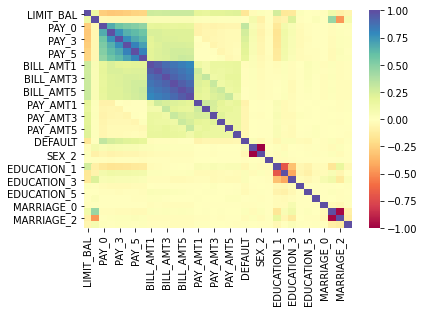

In [ ]:
sns.heatmap(cc_data.corr(), cmap="Spectral")

In [ ]:
cc_data.corr()['DEFAULT'].sort_values(ascending=False)

DEFAULT        1.000000
PAY_0          0.324794
PAY_2          0.263551
PAY_3          0.235253
PAY_4          0.216614
PAY_5          0.204149
PAY_6          0.186866
SEX_1          0.039961
EDUCATION_2    0.036467
EDUCATION_3    0.032403
MARRIAGE_1     0.029775
AGE            0.013890
MARRIAGE_3     0.009768
BILL_AMT6     -0.005372
EDUCATION_6   -0.006397
BILL_AMT5     -0.006760
BILL_AMT4     -0.010156
EDUCATION_0   -0.011516
MARRIAGE_0    -0.013158
BILL_AMT3     -0.014076
BILL_AMT2     -0.014193
BILL_AMT1     -0.019644
EDUCATION_4   -0.025397
MARRIAGE_2    -0.030619
EDUCATION_5   -0.036695
SEX_2         -0.039961
EDUCATION_1   -0.051328
PAY_AMT6      -0.053183
PAY_AMT5      -0.055124
PAY_AMT3      -0.056250
PAY_AMT4      -0.056827
PAY_AMT2      -0.058579
PAY_AMT1      -0.072929
LIMIT_BAL     -0.153520
Name: DEFAULT, dtype: float64

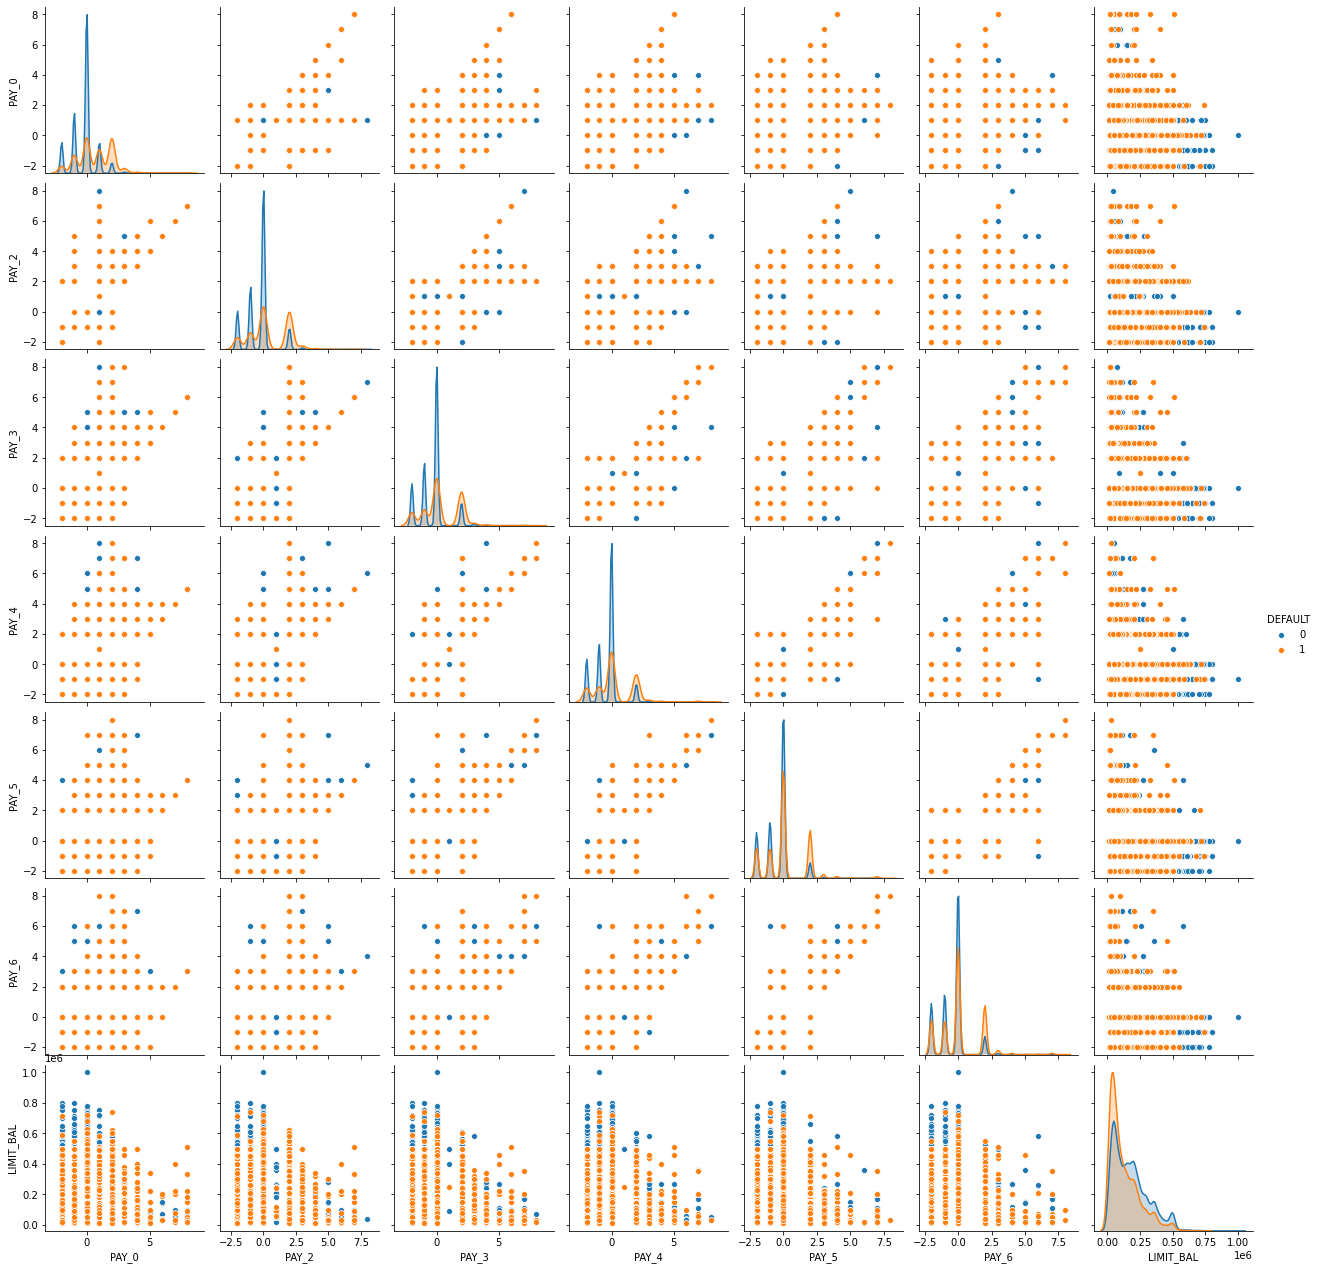

In [ ]:
sns.pairplot(cc_data[['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6','LIMIT_BAL','DEFAULT']],hue='DEFAULT')

In [6]:
# Preparing features and labels

X = cc_data.drop('DEFAULT',axis=1).values
y = cc_data['DEFAULT'].values

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=1)

In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Activation,Dropout

In [ ]:
X_train.shape

(22500, 33)

In [ ]:
model = Sequential()

# Suggested reading - How to choose the number of hidden layers and nodes
# https://stats.stackexchange.com/questions/181/how-to-choose-the-number-of-hidden-layers-and-nodes-in-a-feedforward-neural-netw

model.add(Dense(units=30,activation='relu'))
model.add(Dense(units=15,activation='relu'))
model.add(Dense(units=1,activation='sigmoid'))

# For a binary classification problem
model.compile(loss='binary_crossentropy', optimizer='adam')

In [ ]:
# Suggested readings
# https://stats.stackexchange.com/questions/164876/tradeoff-batch-size-vs-number-of-iterations-to-train-a-neural-network
# https://datascience.stackexchange.com/questions/18414/are-there-any-rules-for-choosing-the-size-of-a-mini-batch

model.fit(x=X_train, 
          y=y_train,
          batch_size=128, 
          epochs=100,
          validation_data=(X_test, y_test), verbose=1
          )

Epoch 1/100
176/176 [==============================] - 1s 4ms/step - loss: 0.5710 - val_loss: 0.4999
Epoch 2/100
176/176 [==============================] - 1s 4ms/step - loss: 0.4903 - val_loss: 0.4721
Epoch 3/100
176/176 [==============================] - 1s 4ms/step - loss: 0.4699 - val_loss: 0.4577
Epoch 4/100
176/176 [==============================] - 1s 4ms/step - loss: 0.4600 - val_loss: 0.4544
Epoch 5/100
176/176 [==============================] - 1s 4ms/step - loss: 0.4542 - val_loss: 0.4449
Epoch 6/100
176/176 [==============================] - 1s 4ms/step - loss: 0.4496 - val_loss: 0.4413
Epoch 7/100
176/176 [==============================] - 1s 4ms/step - loss: 0.4477 - val_loss: 0.4399
Epoch 8/100
176/176 [==============================] - 1s 3ms/step - loss: 0.4453 - val_loss: 0.4400
Epoch 9/100
176/176 [==============================] - 1s 4ms/step - loss: 0.4443 - val_loss: 0.4384
Epoch 10/100
176/176 [==============================] - 1s 4ms/step - loss: 0.4429 - val_lo

In [ ]:
# model.history.history

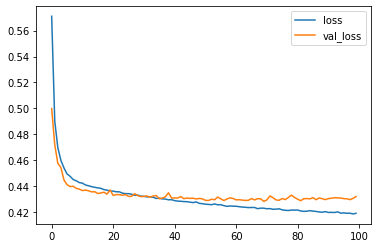

In [ ]:
model_loss = pd.DataFrame(model.history.history)
model_loss.plot()

In [11]:
# Early stopping example

from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# Sequential 

model = Sequential()
model.add(Dense(units=30,activation='relu'))
model.add(Dense(units=15,activation='relu'))
model.add(Dense(units=1,activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam')

In [15]:
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)

In [ ]:
model.fit(x=X_train, 
          y=y_train, 
          batch_size=128,
          epochs=100,
          validation_data=(X_test, y_test), verbose=1,
          callbacks=[early_stop]
          )

Epoch 1/100
176/176 [==============================] - 1s 4ms/step - loss: 0.5468 - val_loss: 0.5022
Epoch 2/100
176/176 [==============================] - 1s 4ms/step - loss: 0.4871 - val_loss: 0.4665
Epoch 3/100
176/176 [==============================] - 1s 4ms/step - loss: 0.4672 - val_loss: 0.4574
Epoch 4/100
176/176 [==============================] - 1s 4ms/step - loss: 0.4602 - val_loss: 0.4506
Epoch 5/100
176/176 [==============================] - 1s 4ms/step - loss: 0.4552 - val_loss: 0.4522
Epoch 6/100
176/176 [==============================] - 1s 4ms/step - loss: 0.4534 - val_loss: 0.4444
Epoch 7/100
176/176 [==============================] - 1s 4ms/step - loss: 0.4499 - val_loss: 0.4462
Epoch 8/100
176/176 [==============================] - 1s 4ms/step - loss: 0.4485 - val_loss: 0.4419
Epoch 9/100
176/176 [==============================] - 1s 4ms/step - loss: 0.4471 - val_loss: 0.4401
Epoch 10/100
176/176 [==============================] - 1s 4ms/step - loss: 0.4462 - val_lo

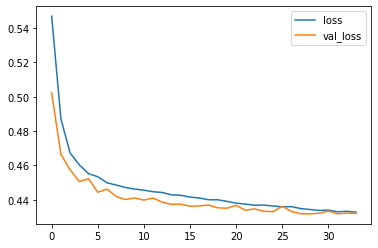

In [ ]:
model_loss = pd.DataFrame(model.history.history)
model_loss.plot()

In [12]:
# Example with Dropout

from tensorflow.keras.layers import Dropout

In [13]:
model = Sequential()
model.add(Dense(units=30,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(units=15,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(units=1,activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam')

In [16]:
model.fit(x=X_train, 
          y=y_train, 
          batch_size=128,
          epochs=200,
          validation_data=(X_test, y_test), verbose=1,
          callbacks=[early_stop]
          )

Epoch 1/200
176/176 [==============================] - 4s 4ms/step - loss: 0.5845 - val_loss: 0.5211
Epoch 2/200
176/176 [==============================] - 1s 3ms/step - loss: 0.5318 - val_loss: 0.4979
Epoch 3/200
176/176 [==============================] - 1s 3ms/step - loss: 0.5149 - val_loss: 0.4870
Epoch 4/200
176/176 [==============================] - 1s 3ms/step - loss: 0.5032 - val_loss: 0.4764
Epoch 5/200
176/176 [==============================] - 1s 3ms/step - loss: 0.4941 - val_loss: 0.4700
Epoch 6/200
176/176 [==============================] - 1s 3ms/step - loss: 0.4865 - val_loss: 0.4661
Epoch 7/200
176/176 [==============================] - 1s 3ms/step - loss: 0.4817 - val_loss: 0.4644
Epoch 8/200
176/176 [==============================] - 1s 3ms/step - loss: 0.4797 - val_loss: 0.4592
Epoch 9/200
176/176 [==============================] - 1s 3ms/step - loss: 0.4746 - val_loss: 0.4575
Epoch 10/200
176/176 [==============================] - 1s 3ms/step - loss: 0.4735 - val_lo

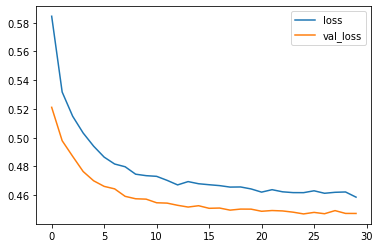

In [17]:
model_loss = pd.DataFrame(model.history.history)
model_loss.plot()

In [18]:
y_pred =(model.predict(X_test) > 0.5).astype("int32")

In [19]:
from sklearn.metrics import classification_report,confusion_matrix, roc_auc_score

In [20]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.97      0.89      5832
           1       0.70      0.29      0.41      1668

    accuracy                           0.81      7500
   macro avg       0.76      0.63      0.65      7500
weighted avg       0.80      0.81      0.78      7500



In [21]:
print(confusion_matrix(y_test,y_pred))
print('ROC AUC: ', roc_auc_score(y_test,model.predict(X_test)))

[[5631  201]
 [1191  477]]
ROC AUC:  0.7578942504432667
